#  Machine Learning Analysis

Notebook này xây dựng ** pipeline ML** :

| Dataset | Bài toán | Mô hình |
|---------|----------|---------|
| **E-commerce Olist** | Dự đoán Review Score (1–5) | XGBoost Classifier |

---

##  Setup & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#4361ee', '#3a0ca3', '#7209b7', '#f72585', '#4cc9f0']
print(' Thư viện đã sẵn sàng')

 Thư viện đã sẵn sàng


---
#  E-Commerce Olist — Dự đoán Review Score

###  Bài toán
Dự đoán **mức độ hài lòng của khách hàng** (review score 1–5 sao) dựa trên thông tin đơn hàng, giao hàng, thanh toán và sản phẩm.

###  Nguồn bảng dữ liệu
```
orders ──┬── order_items ── products ── category_translation
         ├── payments
         ├── reviews  (TARGET)
         └── customers ── geolocation
                              └── sellers
```

## 1.1 Load & Merge Data

In [2]:
DATA_PATH = './data/clean/'  
orders      = pd.read_csv(DATA_PATH + 'orders_clean.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
order_items = pd.read_csv(DATA_PATH + 'order_items_clean.csv', parse_dates=['shipping_limit_date'])
payments    = pd.read_csv(DATA_PATH + 'payments_clean.csv')
reviews     = pd.read_csv(DATA_PATH + 'reviews_clean.csv')
customers   = pd.read_csv(DATA_PATH + 'customers_clean.csv')
products    = pd.read_csv(DATA_PATH + 'products_clean.csv')
sellers     = pd.read_csv(DATA_PATH + 'sellers_clean.csv')
category    = pd.read_csv(DATA_PATH + 'category_translation_clean.csv')
geolocation = pd.read_csv(DATA_PATH + 'geolocation_clean.csv')

print(f'orders:      {orders.shape}')
print(f'order_items: {order_items.shape}')
print(f'payments:    {payments.shape}')
print(f'reviews:     {reviews.shape}')
print(f'products:    {products.shape}')

orders:      (99441, 8)
order_items: (112650, 7)
payments:    (103886, 5)
reviews:     (99224, 7)
products:    (32951, 9)


## 1.2 Feature Engineering từng bảng

In [3]:
# ─────────────────────────────────────────────
# A. FEATURES TỪ BẢNG orders — Thông tin giao hàng
# ─────────────────────────────────────────────
orders_feat = orders.copy()

# Chỉ giữ đơn đã delivered
orders_feat = orders_feat[orders_feat['order_status'] == 'delivered'].copy()

# F1: Số ngày từ purchase → approve
orders_feat['approval_delay_days'] = (
    orders_feat['order_approved_at'] - orders_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

# F2: Số ngày giao hàng thực tế
orders_feat['actual_delivery_days'] = (
    orders_feat['order_delivered_customer_date'] - orders_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

# F3: Số ngày giao hàng dự kiến
orders_feat['estimated_delivery_days'] = (
    orders_feat['order_estimated_delivery_date'] - orders_feat['order_purchase_timestamp']
).dt.total_seconds() / 86400

# F4: Giao sớm (+) hay trễ (-) so với dự kiến
orders_feat['delivery_diff_days'] = (
    orders_feat['order_estimated_delivery_date'] - orders_feat['order_delivered_customer_date']
).dt.total_seconds() / 86400

# F5: Giao trễ hay không (binary)
orders_feat['is_late_delivery'] = (orders_feat['delivery_diff_days'] < 0).astype(int)

# F6: Thời gian từ carrier nhận → khách nhận
orders_feat['carrier_to_customer_days'] = (
    orders_feat['order_delivered_customer_date'] - orders_feat['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# F7: Ngày trong tuần đặt hàng
orders_feat['purchase_dayofweek'] = orders_feat['order_purchase_timestamp'].dt.dayofweek
orders_feat['purchase_hour']      = orders_feat['order_purchase_timestamp'].dt.hour
orders_feat['purchase_month']     = orders_feat['order_purchase_timestamp'].dt.month



In [5]:
orders_feat.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay_days,actual_delivery_days,estimated_delivery_days,delivery_diff_days,is_late_delivery,carrier_to_customer_days,purchase_dayofweek,purchase_hour,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.007431,8.436574,15.544063,7.107488,0,6.062650,0,10,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.279745,13.782037,19.137766,5.355729,0,12.039410,1,20,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.011505,9.394213,26.639711,17.245498,0,9.178113,2,8,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.012419,13.208750,26.188819,12.980069,0,9.450498,5,19,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0.042940,2.873877,12.112049,9.238171,0,1.937824,1,21,2


In [7]:
orders_feat.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
approval_delay_days              14
actual_delivery_days              8
estimated_delivery_days           0
delivery_diff_days                8
is_late_delivery                  0
carrier_to_customer_days          9
purchase_dayofweek                0
purchase_hour                     0
purchase_month                    0
dtype: int64

In [8]:
orders_sel = orders_feat[[
    'order_id', 'customer_id',
    'approval_delay_days', 'actual_delivery_days', 'estimated_delivery_days',
    'delivery_diff_days', 'is_late_delivery', 'carrier_to_customer_days',
    'purchase_dayofweek', 'purchase_hour', 'purchase_month'
]].dropna(subset=['actual_delivery_days'])

print(f' orders features: {orders_sel.shape}  →  {orders_sel.columns.tolist()}')


 orders features: (96470, 11)  →  ['order_id', 'customer_id', 'approval_delay_days', 'actual_delivery_days', 'estimated_delivery_days', 'delivery_diff_days', 'is_late_delivery', 'carrier_to_customer_days', 'purchase_dayofweek', 'purchase_hour', 'purchase_month']


In [9]:
orders_sel.isnull().sum()

order_id                     0
customer_id                  0
approval_delay_days         14
actual_delivery_days         0
estimated_delivery_days      0
delivery_diff_days           0
is_late_delivery             0
carrier_to_customer_days     1
purchase_dayofweek           0
purchase_hour                0
purchase_month               0
dtype: int64

In [ ]:
# ─────────────────────────────────────────────
# B. FEATURES TỪ BẢNG order_items — Sản phẩm & giá
# ─────────────────────────────────────────────
items_feat = order_items.groupby('order_id').agg(
    n_items          = ('order_item_id', 'max'),         # F8: Số sản phẩm trong đơn
    n_unique_product = ('product_id', 'nunique'),        # F9: Số sản phẩm khác nhau
    n_unique_seller  = ('seller_id', 'nunique'),         # F10: Số seller khác nhau
    total_price      = ('price', 'sum'),                 # F11: Tổng giá trị đơn hàng
    avg_item_price   = ('price', 'mean'),                # F12: Giá trung bình mỗi item
    max_item_price   = ('price', 'max'),                 # F13: Giá item đắt nhất
    total_freight    = ('freight_value', 'sum'),         # F14: Phí vận chuyển tổng
    avg_freight      = ('freight_value', 'mean'),        # F15: Phí vận chuyển TB
).reset_index()

# F16: Tỷ lệ phí ship / tổng đơn hàng
items_feat['freight_ratio'] = items_feat['total_freight'] / (items_feat['total_price'] + 0.01)

print(f' order_items features: {items_feat.shape}')

✅ order_items features: (98666, 10)


In [ ]:
# ─────────────────────────────────────────────
# C. FEATURES TỪ BẢNG payments — Thanh toán
# ─────────────────────────────────────────────
pay_feat = payments.groupby('order_id').agg(
    total_payment_value  = ('payment_value', 'sum'),        # F17: Tổng tiền thanh toán
    n_payment_methods    = ('payment_type', 'nunique'),     # F18: Số phương thức TT
    max_installments     = ('payment_installments', 'max'), # F19: Số kỳ trả góp tối đa
    n_payment_seq        = ('payment_sequential', 'max'),   # F20: Số lần thanh toán
).reset_index()

# F21: Phương thức thanh toán chính (sequential=1)
primary_pay = payments[payments['payment_sequential'] == 1][['order_id', 'payment_type']].copy()
primary_pay = primary_pay.rename(columns={'payment_type': 'primary_payment_type'})

pay_feat = pay_feat.merge(primary_pay, on='order_id', how='left')

# F22: Có dùng trả góp không
pay_feat['has_installments'] = (pay_feat['max_installments'] > 1).astype(int)

print(f' payments features: {pay_feat.shape}')

✅ payments features: (99440, 7)


In [ ]:
# ─────────────────────────────────────────────
# D. FEATURES TỪ BẢNG products — Thuộc tính sản phẩm
# ─────────────────────────────────────────────
products_with_cat = products.merge(category, on='product_category_name', how='left')

# Join items → products để lấy category theo order
items_product = order_items[['order_id', 'product_id']].merge(
    products_with_cat[[
        'product_id', 'product_category_name_english',
        'product_weight_g', 'product_photos_qty',
        'product_description_lenght', 'product_name_lenght'
    ]],
    on='product_id', how='left'
)

prod_feat = items_product.groupby('order_id').agg(
    avg_weight_g      = ('product_weight_g', 'mean'),         # F23: Trọng lượng TB
    avg_photos        = ('product_photos_qty', 'mean'),       # F24: Số ảnh SP TB
    avg_desc_length   = ('product_description_lenght', 'mean'), # F25: Độ dài mô tả
    avg_name_length   = ('product_name_lenght', 'mean'),      # F26: Độ dài tên SP
).reset_index()

# F27: Category chính của đơn hàng (category đầu tiên)
main_cat = items_product.groupby('order_id')['product_category_name_english'].first().reset_index()
main_cat.columns = ['order_id', 'main_category']
prod_feat = prod_feat.merge(main_cat, on='order_id', how='left')

print(f' products features: {prod_feat.shape}')

✅ products features: (98666, 6)


In [ ]:
# ─────────────────────────────────────────────
# E. FEATURES TỪ BẢNG customers + geolocation
# ─────────────────────────────────────────────
# Lấy lat/lng trung bình theo zip code (deduplicate)
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat = ('geolocation_lat', 'mean'),
    lng = ('geolocation_lng', 'mean')
).reset_index()

cust_geo = customers.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)[['customer_id', 'customer_state', 'lat', 'lng']]

# F28: State khách hàng (encode label)
# F29-30: Lat/Lng vị trí khách hàng
print(f' customer+geo features: {cust_geo.shape}')

✅ customer+geo features: (99441, 4)


## 1.3 Merge tất cả Features & chuẩn bị TARGET

In [12]:
# Target: review score
review_target = reviews[['order_id', 'review_score']].drop_duplicates('order_id')

# Merge pipeline
df = (
    orders_sel
    .merge(items_feat,    on='order_id', how='left')
    .merge(pay_feat,      on='order_id', how='left')
    .merge(prod_feat,     on='order_id', how='left')
    .merge(cust_geo,      on='customer_id', how='left')
    .merge(review_target, on='order_id', how='inner')
)

print(f'Dataset sau merge: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Dataset sau merge: (95824, 35)
Missing values:
approval_delay_days           14
carrier_to_customer_days       1
total_payment_value            1
n_payment_methods              1
max_installments               1
n_payment_seq                  1
primary_payment_type          78
has_installments               1
main_category               1343
lat                          263
lng                          263
dtype: int64


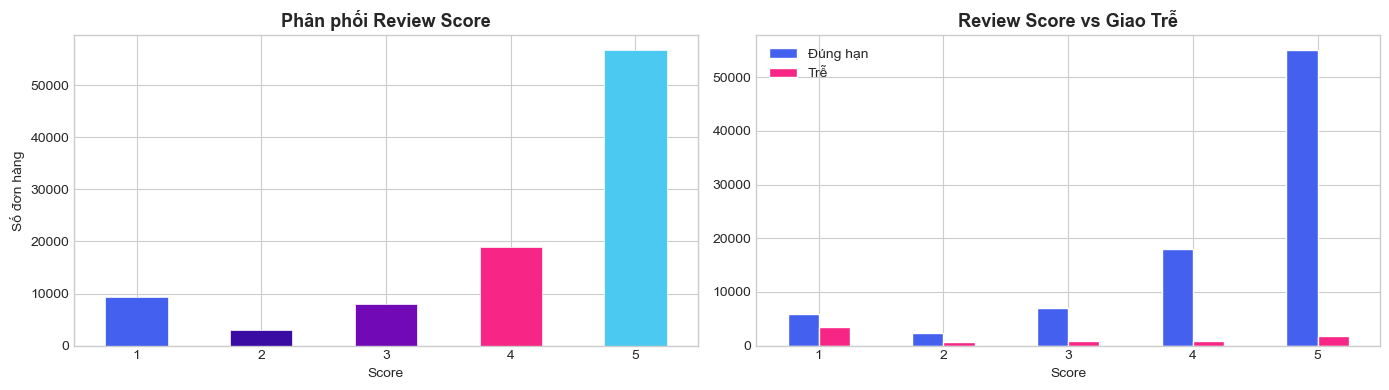

In [ ]:
# Phân phối review score
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=PALETTE, edgecolor='white', linewidth=0.5
)
axes[0].set_title('Phân phối Review Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Số đơn hàng')
axes[0].tick_params(axis='x', rotation=0)

# Late delivery vs score
df.groupby(['review_score', 'is_late_delivery']).size().unstack().plot(
    kind='bar', ax=axes[1], color=[PALETTE[0], PALETTE[3]], edgecolor='white'
)
axes[1].set_title('Review Score vs Giao Trễ', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].legend(['Đúng hạn', 'Trễ'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 1.4 Preprocessing

In [14]:
# ── Chọn features ──
NUMERIC_FEATURES = [
    # Delivery timing
    'approval_delay_days', 'actual_delivery_days', 'estimated_delivery_days',
    'delivery_diff_days', 'is_late_delivery', 'carrier_to_customer_days',
    # Time features
    'purchase_dayofweek', 'purchase_hour', 'purchase_month',
    # Order items
    'n_items', 'n_unique_product', 'n_unique_seller',
    'total_price', 'avg_item_price', 'max_item_price',
    'total_freight', 'avg_freight', 'freight_ratio',
    # Payment
    'total_payment_value', 'n_payment_methods', 'max_installments',
    'n_payment_seq', 'has_installments',
    # Product
    'avg_weight_g', 'avg_photos', 'avg_desc_length', 'avg_name_length',
    # Location
    'lat', 'lng',
]

CAT_FEATURES = ['primary_payment_type', 'customer_state', 'main_category']

TARGET = 'review_score'

# ── Encode categoricals ──
le_dict = {}
df_ml = df[NUMERIC_FEATURES + CAT_FEATURES + [TARGET]].copy()

for col in CAT_FEATURES:
    df_ml[col] = df_ml[col].fillna('unknown')
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

# ── Fill missing & clip outliers ──
df_ml = df_ml.fillna(df_ml.median(numeric_only=True))

# Clip extreme delivery values
df_ml['actual_delivery_days'] = df_ml['actual_delivery_days'].clip(0, 120)
df_ml['delivery_diff_days']   = df_ml['delivery_diff_days'].clip(-60, 60)

ALL_FEATURES = NUMERIC_FEATURES + CAT_FEATURES

X = df_ml[ALL_FEATURES]
y = df_ml[TARGET]

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{y.value_counts().sort_index()}')

Feature matrix: (95824, 32)
Target distribution:
review_score
1     9343
2     2923
3     7908
4    18893
5    56757
Name: count, dtype: int64


In [15]:
# ── Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (76659, 32) | Test: (19165, 32)


## 1.5 Mô hình ML: XGBoost Classifier

**Lý do chọn XGBoost:**
- Xử lý tốt dữ liệu tabular với nhiều features
- Robust với outliers và missing values
- Tự nhiên xử lý multiclass (5 classes: 1–5 sao)
- Feature importance rõ ràng và có thể giải thích

In [16]:
# XGBoost — convert score sang 0-indexed
y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

xgb_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'multi:softmax',
    num_class        = 5,
    use_label_encoder=False,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_model.fit(
    X_train, y_train_xgb,
    eval_set=[(X_test, y_test_xgb)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test) + 1  # convert về 1-5

acc = accuracy_score(y_test, y_pred_xgb)
f1  = f1_score(y_test, y_pred_xgb, average='weighted')
print(f'XGBoost Accuracy:  {acc:.4f}')
print(f'XGBoost F1 (weighted): {f1:.4f}')

XGBoost Accuracy:  0.6211
XGBoost F1 (weighted): 0.4981


In [18]:
print('\n Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['⭐1', '⭐⭐2', '⭐⭐⭐3', '⭐⭐⭐⭐4', '⭐⭐⭐⭐⭐5']))


 Classification Report:
              precision    recall  f1-score   support

          ⭐1       0.61      0.38      0.47      1869
         ⭐⭐2       0.00      0.00      0.00       584
        ⭐⭐⭐3       0.00      0.00      0.00      1582
       ⭐⭐⭐⭐4       0.18      0.00      0.00      3779
      ⭐⭐⭐⭐⭐5       0.62      0.99      0.76     11351

    accuracy                           0.62     19165
   macro avg       0.28      0.27      0.25     19165
weighted avg       0.46      0.62      0.50     19165



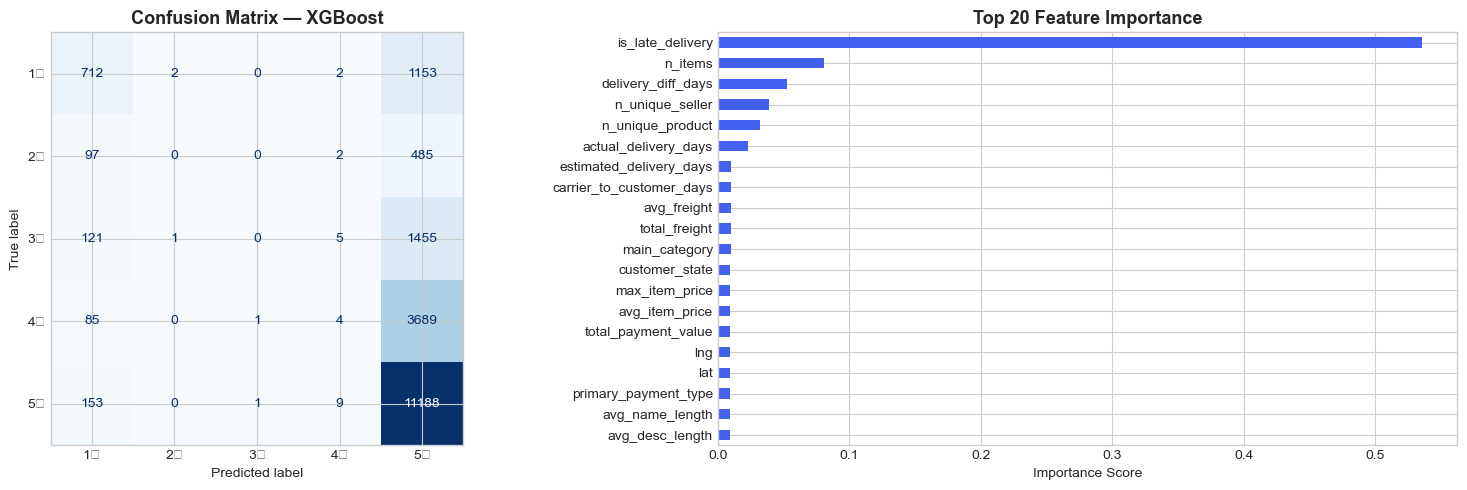

In [19]:
# Confusion Matrix + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['1⭐','2⭐','3⭐','4⭐','5⭐'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')

# Feature Importance (top 20)
fi = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True).tail(20)
fi.plot(kind='barh', ax=axes[1], color=PALETTE[0])
axes[1].set_title('Top 20 Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [20]:
# So sánh với Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== So sánh mô hình ===')
print(f'XGBoost  — Acc: {accuracy_score(y_test, y_pred_xgb):.4f}  |  F1: {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
print(f'Random Forest — Acc: {accuracy_score(y_test, y_pred_rf):.4f}  |  F1: {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')

=== So sánh mô hình ===
XGBoost  — Acc: 0.6211  |  F1: 0.4981
Random Forest — Acc: 0.6211  |  F1: 0.4969
